# setup device

In [505]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# setup Dataset

In [506]:
from torch.utils.data import Dataset
import os
import random
from PIL import Image


class TripletLossDataset(Dataset):
    def __init__(self, split='train', transform=None, max_samples=None, allowed_classes=None,
                 max_samples_per_class=None):
        """
        returns: anc_img, pos_img, neg_img, anc_class, neg_class
        :param split:
        :param transform:
        :param max_samples:
        :param allowed_classes:
        :param max_samples_per_class:
        """

        assert split in ["train", "test", "val"], "split must be 'train' or 'test' or 'val'"

        label_files = {
            'train': 'data/RVL_CDIP/labels/train.txt',
            'test': 'data/RVL_CDIP/labels/test.txt',
            "val": "data/RVL_CDIP/labels/val.txt"
        }

        root_dir = "data/RVL_CDIP/images"
        label_file = label_files[split]

        self.label_to_images = {}
        self.image_to_label = {}
        self.all_images = []

        self.allowed_classes = allowed_classes
        self.class_map = {cls: i for i, cls in enumerate(allowed_classes)} if allowed_classes else None

        with open(label_file, 'r') as f:
            for line in f:

                path, label = line.strip().split()
                full_path = os.path.join(root_dir, path)
                label = int(label)

                if allowed_classes is not None and label not in allowed_classes:
                    continue

                if label not in self.label_to_images:
                    self.label_to_images[label] = []

                if max_samples_per_class is not None and len(self.label_to_images[label]) >= max_samples_per_class:
                    continue

                if max_samples is not None and len(self) >= max_samples:
                    break

                self.label_to_images[label].append(full_path)
                self.image_to_label[full_path] = label
                self.all_images.append((full_path, label))

        self.labels = list(self.label_to_images.keys())
        self.transform = transform

    def num_classes(self):
        return len(self.label_to_images.keys())

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, idx):
        anc_path, anc_class = self.all_images[idx]

        pos_path = random.choice([
            path for path in self.label_to_images[anc_class] if path != anc_path
        ])
        neg_class = random.choice([l for l in self.labels if l != anc_class])
        neg_path = random.choice(self.label_to_images[neg_class])

        anc_img = Image.open(anc_path)
        pos_img = Image.open(pos_path)
        neg_img = Image.open(neg_path)

        if self.transform:
            anc_img = self.transform(anc_img)
            pos_img = self.transform(pos_img)
            neg_img = self.transform(neg_img)

        if self.class_map:
            anc_class = self.class_map[anc_class]  # z.B. 2 → 0, 6 → 1
            neg_class = self.class_map[neg_class]

        return anc_img, pos_img, neg_img, anc_class, neg_class

# setup Hyperparams

In [507]:
from itertools import product

template_count_variations = [1, 2, 5]
template_strategy_variations = ["RANDOM", "DISTANT"]

allowed_class_variations = [
    [4, 8],
    [4, 7, 8, 12],
    [1, 2, 4, 7, 8, 11, 12, 14],
]

new_allowed_class_variations = [
    [4, 8, 12],
    [4, 7, 8, 12, 14],
    [1, 2, 4, 7, 8, 10, 11, 12, 14],
]

combinations = []

for count, strategy in product(template_count_variations, template_strategy_variations):
    for classic, new in zip(allowed_class_variations, new_allowed_class_variations):
        combo = {
            "template_count": count,
            "template_strategy": strategy,
            "allowed_classes": classic,
            "new_allowed_classes": new
        }
        combinations.append(combo)


def print_combinations(selected_index=None):
    for i, combo in enumerate(combinations):
        print(f"Index {i}:")
        print(f"  Template Count     : {combo['template_count']}")
        print(f"  Template Strategy  : {combo['template_strategy']}")
        print(f"  Allowed Classes    : {combo['allowed_classes']}")
        print(f"  New Allowed Classes: {combo['new_allowed_classes']}")
        print(f"  Len Allowed Classes: {len(combo['allowed_classes'])}")
        print("-" * 40)

    if selected_index is not None:
        selected_combo = combinations[selected_index]
        print(f"\nCHOSEN COMBINATION (Index {selected_index}):")
        print(f"  Template Count     : {selected_combo['template_count']}")
        print(f"  Template Strategy  : {selected_combo['template_strategy']}")
        print(f"  Allowed Classes    : {selected_combo['allowed_classes']}")
        print(f"  New Allowed Classes: {selected_combo['new_allowed_classes']}")
        print(f"  Len Allowed Classes: {len(selected_combo['allowed_classes'])}")
        return selected_combo
    return None


# Beispiel: Auswahl über Index
var = 17
selected_combo = print_combinations(var)

# Zugriff auf die einzelnen Elemente, wenn du sie brauchst:
ALLOWED_CLASSES = selected_combo["allowed_classes"]
NEW_ALLOWED_CLASSES = selected_combo["new_allowed_classes"]
TEMPLATE_COUNT = selected_combo["template_count"]
TEMPLATE_STRATEGY = selected_combo["template_strategy"]

FOLDER_STR = f"confusion_matrices/triplet_new_distant_strategy/{len(ALLOWED_CLASSES)}_classes/{TEMPLATE_STRATEGY}_strategy/{TEMPLATE_COUNT}_templates"
print(f"\n{FOLDER_STR}")


Index 0:
  Template Count     : 1
  Template Strategy  : RANDOM
  Allowed Classes    : [4, 8]
  New Allowed Classes: [4, 8, 12]
  Len Allowed Classes: 2
----------------------------------------
Index 1:
  Template Count     : 1
  Template Strategy  : RANDOM
  Allowed Classes    : [4, 7, 8, 12]
  New Allowed Classes: [4, 7, 8, 12, 14]
  Len Allowed Classes: 4
----------------------------------------
Index 2:
  Template Count     : 1
  Template Strategy  : RANDOM
  Allowed Classes    : [1, 2, 4, 7, 8, 11, 12, 14]
  New Allowed Classes: [1, 2, 4, 7, 8, 10, 11, 12, 14]
  Len Allowed Classes: 8
----------------------------------------
Index 3:
  Template Count     : 1
  Template Strategy  : DISTANT
  Allowed Classes    : [4, 8]
  New Allowed Classes: [4, 8, 12]
  Len Allowed Classes: 2
----------------------------------------
Index 4:
  Template Count     : 1
  Template Strategy  : DISTANT
  Allowed Classes    : [4, 7, 8, 12]
  New Allowed Classes: [4, 7, 8, 12, 14]
  Len Allowed Classes: 4

## dataset size

In [508]:
from torch.utils.data import DataLoader
from torchvision import transforms

IMAGE_SIZE = (224, 224)

# Define a basic transform
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),  # resize to a standard size
    transforms.ToTensor()  # convert to tensor
])

original_dataset_length = 0
with open("data/RVL_CDIP/labels/train.txt", "r") as f:
    original_dataset_length = sum(1 for _ in f)
print(original_dataset_length)

MAX_SAMPLES = original_dataset_length

BATCH_SIZE = 32

320000


In [509]:
# Create the dataset instance
train_dataset = TripletLossDataset(split='train', transform=transform, max_samples=MAX_SAMPLES,
                                   allowed_classes=ALLOWED_CLASSES)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataset = TripletLossDataset(split="test", transform=transform, max_samples=1000,
                                  allowed_classes=ALLOWED_CLASSES)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## class names

In [510]:
class_names = {
    0: "letter",
    1: "form",
    2: "email",
    3: "handwritten",
    4: "advertisement",
    5: "scientific report",
    6: "scientific publication",
    7: "specification",
    8: "file folder",
    9: "news article",
    10: "budget",
    11: "invoice",
    12: "presentation",
    13: "questionnaire",
    14: "resume",
    15: "memo"
}

### printing an plotting example batch

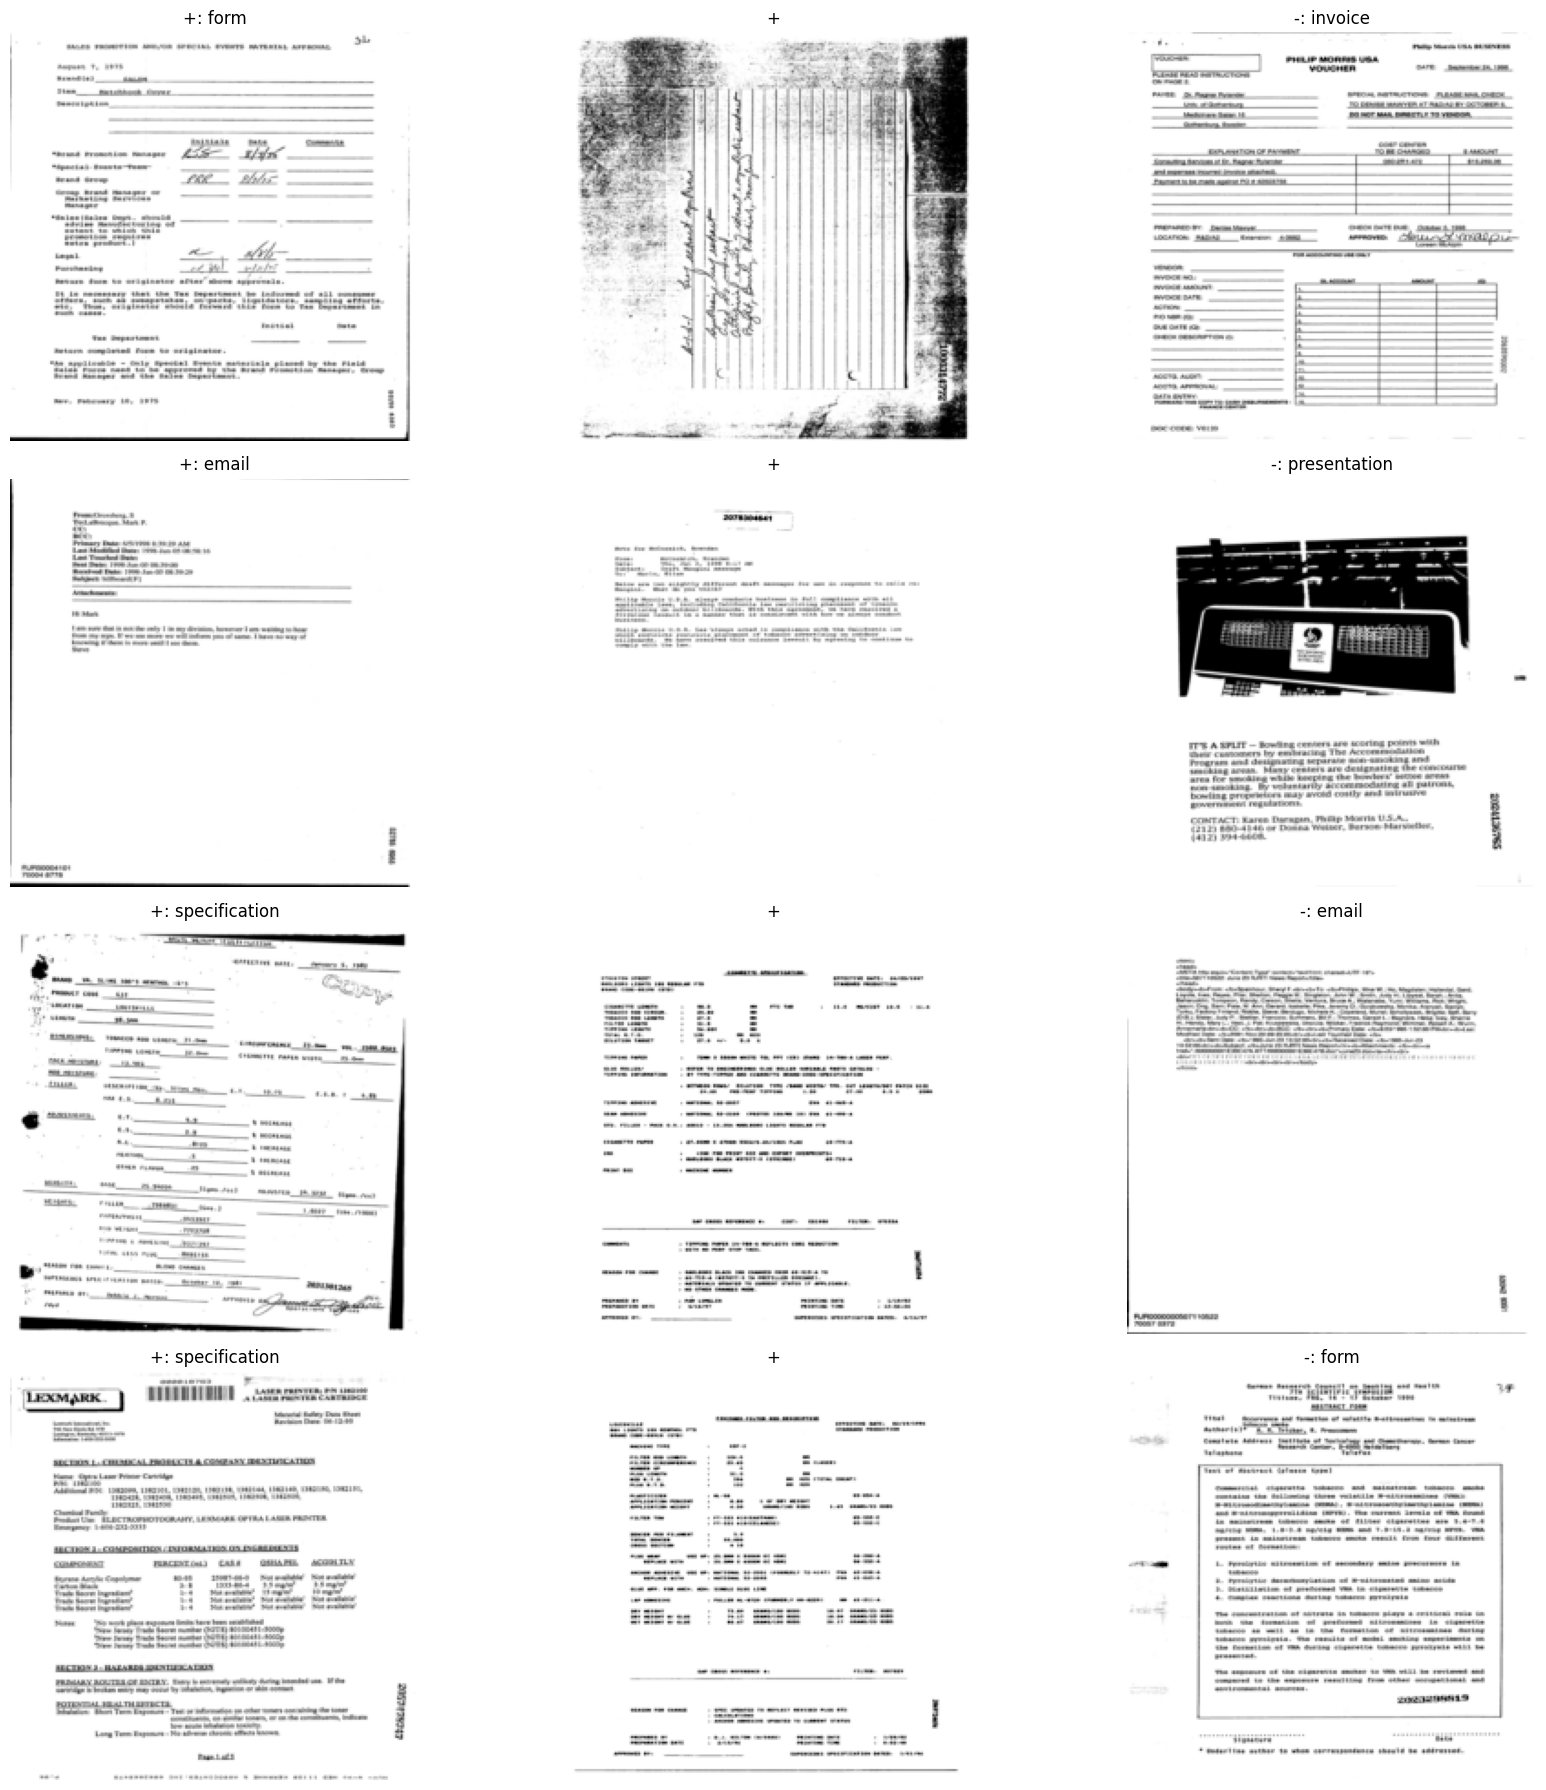

In [511]:
import matplotlib.pyplot as plt

sample_batch = next(iter(train_dataloader))
anchor_batch, positive_batch, negative_batch, anchor_class, negative_class = sample_batch

# Plot the 8 triplets
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 18))

for i in range(4):
    anchor = anchor_batch[i].squeeze()
    positive = positive_batch[i].squeeze()
    negative = negative_batch[i].squeeze()

    # Falls es noch Tensoren sind, konvertieren
    if hasattr(anchor, "numpy"):
        anchor = anchor.cpu().numpy()
        positive = positive.cpu().numpy()
        negative = negative.cpu().numpy()

    # Hole die gemappten Klassen und Labels
    anchor_label_idx = ALLOWED_CLASSES[anchor_class[i].item()]
    anchor_label = class_names[anchor_label_idx]

    negative_label_idx = ALLOWED_CLASSES[negative_class[i].item()]
    negative_label = class_names[negative_label_idx]

    # Anchor image
    axes[i, 0].imshow(anchor, cmap='gray')
    axes[i, 0].set_title(f"+: {anchor_label}")
    axes[i, 0].axis('off')

    # Positive image (kein Mapping nötig)
    axes[i, 1].imshow(positive, cmap='gray')
    axes[i, 1].set_title("+")
    axes[i, 1].axis('off')

    # Negative image
    axes[i, 2].imshow(negative, cmap='gray')
    axes[i, 2].set_title(f"-: {negative_label}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


# setup Model

In [512]:
import torch
from torch import nn
from torchvision import models


class ResNet18Model(nn.Module):
    def __init__(self, input_shape: int, output_shape: int):
        super().__init__()
        self.model = models.resnet18()

        if input_shape == 1:
            self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, output_shape)

    def forward(self, x):
        return self.model(x)


# triplet loss

In [513]:
import torch.nn.functional as F


def triplet_loss_hard_mining(anchor_batch, positive_batch, negative_batch, margin=1.0):
    # Berechne Distanzen für jedes Triplet im Batch (1:1)
    d_ap = F.pairwise_distance(anchor_batch, positive_batch, p=2)
    d_an = F.pairwise_distance(anchor_batch, negative_batch, p=2)

    # Bestimme härteste Triplets: wo d_ap am größten und d_an am kleinsten ist
    k = max(1, anchor_batch.size(0) // 4)

    # Hard positives: größte d_ap
    _, hardest_pos_idx = torch.topk(d_ap, k=k, largest=True)
    # Hard negatives: kleinste d_an
    _, hardest_neg_idx = torch.topk(d_an, k=k, largest=False)

    # Wähle die Distanzen entsprechend
    hard_pos_dists = d_ap[hardest_pos_idx]
    hard_neg_dists = d_an[hardest_neg_idx]

    # Optional: mische zusätzliche zufällige Triplets für Robustheit
    rand_indices = torch.randperm(d_ap.size(0))[:k]
    rand_pos_dists = d_ap[rand_indices]
    rand_neg_dists = d_an[rand_indices]
    all_pos = torch.cat([hard_pos_dists, rand_pos_dists], dim=0)
    all_neg = torch.cat([hard_neg_dists, rand_neg_dists], dim=0)

    # Berechne den finalen Loss
    loss = F.relu(all_pos - all_neg + margin)
    return loss.mean()


def triplet_loss(anchor_batch, positive_batch, negative_batch, margin=1.0):
    # Berechne L2-Distanzen zwischen korrespondierenden Triplets
    d_ap = F.pairwise_distance(anchor_batch, positive_batch, p=2)
    d_an = F.pairwise_distance(anchor_batch, negative_batch, p=2)

    # Standard Triplet Loss
    loss = F.relu(d_ap - d_an + margin)
    return loss.mean()


class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative, hard=False):
        if hard:
            return triplet_loss_hard_mining(anchor, positive, negative, margin=self.margin)
        else:
            return triplet_loss(anchor, positive, negative, margin=self.margin)


# instantiate model etc

In [514]:
print(f"using {device}")
MARGIN = 0.3
net = ResNet18Model(input_shape=1, output_shape=128).to(device)
criterion = TripletLoss(margin=MARGIN).to(device)
optimizer = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=1e-4)

using cuda


### helper func

In [515]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# test step

In [516]:
def test_step(model: nn.Module,
              dataloader: torch.utils.data.DataLoader,
              criterion: nn.Module):
    test_loss = 0.0
    model.eval()
    dataloader_progress = tqdm(dataloader, desc="Testing...", colour="gray")

    with torch.inference_mode():
        for i, (a, p, n, *_) in enumerate(dataloader_progress):
            a, p, n = a.to(device), p.to(device), n.to(device)

            a = model(a)
            p = model(p)
            n = model(n)
            a, p, n = F.normalize(a), F.normalize(p), F.normalize(n)
            loss = criterion(a, p, n, False)  # while testing we want average values, so no hard mining

            test_loss += loss.item()
            avg_test_loss = test_loss / (i + 1)
            dataloader_progress.set_postfix(avg_loss=avg_test_loss)

    return avg_test_loss


# train step

In [517]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               criterion: nn.Module,
               optimizer: torch.optim.Optimizer,
               hard_mining=False,
               test_dataloader=None):
    train_loss = 0.0
    avg_loss = 0.0
    loss_per_batch = []
    model.train()

    dataloader_progress = tqdm(dataloader, desc="Training...")
    for i, (a, p, n, *_) in enumerate(dataloader_progress):
        a, p, n = a.to(device), p.to(device), n.to(device)

        a = model(a)
        p = model(p)
        n = model(n)
        a, p, n = F.normalize(a), F.normalize(p), F.normalize(n)

        if hard_mining and i % 2 == 0:
            h = True
        else:
            h = False
        loss = criterion(a, p, n, h)
        loss_per_batch.append(loss.item())

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        train_loss += loss.item()
        avg_loss = train_loss / (i + 1)
        dataloader_progress.set_postfix(avg_loss=avg_loss)

        if i % 200 == 0:
            avg_distance_ap = F.pairwise_distance(a, p).mean()
            avg_distance_an = F.pairwise_distance(a, n).mean()
            print(f"avg distance anchor positive: {avg_distance_ap}\n"
                  f"avg distance anchor negative: {avg_distance_an}\n")

    plt.figure(figsize=(10, 4))
    plt.plot(loss_per_batch, label='Batch Loss')
    plt.xlabel("Batch Index")
    plt.ylabel("Loss")
    plt.title("Loss pro Batch während Training")
    plt.grid(True)
    plt.legend()
    plt.show()

    return avg_loss

# try to load model

In [518]:
from pathlib import Path

MODEL_PATH = Path("models/triplet")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

skip_training = False
try_to_load_model = True  # True always skips training, False makes overwriting old training data possible

model_name_map = {
    2: "triplet_model_2.pth",
    4: "triplet_model_4.pth",
    8: "triplet_model_8.pth",
}
MODEL_NAME = model_name_map.get(len(ALLOWED_CLASSES), "unnamed_model.pth")
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

if MODEL_SAVE_PATH.exists() and try_to_load_model:
    print(f"loaded model: {MODEL_SAVE_PATH}, skipping training")
    net.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
    skip_training = True
else:
    if try_to_load_model:
        print(f"{MODEL_SAVE_PATH} does not exist, continuing to training")
    else:
        print("loading a model was not desired, continuing to training")
    skip_training = False

loaded model: models\triplet\triplet_model_8.pth, skipping training


### helper func

In [519]:
# helper func
def format_time(seconds):
    minutes = int(seconds // 60)
    seconds = int(seconds % 60)
    return f"{minutes}m {seconds}s"

# visual evaluation

In [520]:
import torch.nn.functional as F
import matplotlib.pyplot as plt


def visualize_triplet_distances(model, dataloader, device, allowed_classes, max_triplets=8):
    """
    Visualizes Euclidean distances between anchor-positive and anchor-negative pairs in a triplet setting.
    Highlights whether the triplet loss condition is satisfied.
    """
    model.eval()

    with torch.inference_mode():
        for a, p, n, anchor_class_labels, negative_class_labels in dataloader:
            a, p, n = a.to(device), p.to(device), n.to(device)

            # Get embeddings
            emb_a = model(a)
            emb_p = model(p)
            emb_n = model(n)
            emb_a, emb_p, emb_n = F.normalize(emb_a), F.normalize(emb_p), F.normalize(emb_n)

            # Compute distances
            dist_ap = F.pairwise_distance(emb_a, emb_p)
            dist_an = F.pairwise_distance(emb_a, emb_n)

            num_triplets = min(max_triplets, len(a))
            fig, axes = plt.subplots(num_triplets, 3, figsize=(9, 3 * num_triplets))
            if num_triplets == 1:
                axes = [axes]

            for i in range(num_triplets):
                a_img = a[i].cpu().squeeze()
                p_img = p[i].cpu().squeeze()
                n_img = n[i].cpu().squeeze()

                ap_dist = dist_ap[i].item()
                an_dist = dist_an[i].item()

                a_class_name = class_names[allowed_classes[anchor_class_labels[i]]]
                n_class_name = class_names[allowed_classes[negative_class_labels[i]]]

                # Check triplet condition
                satisfied = ap_dist < an_dist
                color = 'green' if satisfied else 'red'

                # Anchor
                axes[i][0].imshow(a_img, cmap='gray')
                axes[i][0].set_title(f"Anchor: {a_class_name}", color='black')
                axes[i][0].axis('off')

                # Positive
                axes[i][1].imshow(p_img, cmap='gray')
                axes[i][1].set_title(f"Positive (same): {a_class_name}\nDist: {ap_dist:.2f}", color=color)
                axes[i][1].axis('off')

                # Negative
                axes[i][2].imshow(n_img, cmap='gray')
                axes[i][2].set_title(f"Negative: {n_class_name}\nDist: {an_dist:.2f}", color=color)
                axes[i][2].axis('off')

            plt.tight_layout()
            plt.show()
            break  # Remove to visualize more batches


# training

In [521]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
import matplotlib.pyplot as plt

# Training loop with tqdm progress bar
num_epochs = 3

if not skip_training:
    for epoch in range(num_epochs):
        start = timer()

        if epoch >= 1:
            hard_mining = True
        else:
            hard_mining = False

        print(f"Epoch {epoch + 1}/{num_epochs}: Training...")
        train_step(net, train_dataloader, criterion, optimizer, hard_mining, test_dataloader)

        print(f"Epoch {epoch + 1}/{num_epochs}: Testing...")
        test_step(net, test_dataloader, criterion)

        total_epoch_elapsed = timer() - start
        remaining_time = total_epoch_elapsed * (num_epochs - epoch - 1)
        print(
            f"Epoch duration: {format_time(total_epoch_elapsed)}. "
            f"Estimated remaining time: {format_time(remaining_time)}."
        )

else:
    print(f"loaded a model, skipping training")

loaded a model, skipping training


## saving the model after training

In [522]:
# falls trainiert wurde, speichern, sonst nichts tun
# if not skip_training:
#     print(f"saving model: {MODEL_SAVE_PATH}")
#     torch.save(obj=net.state_dict(), f=MODEL_SAVE_PATH)

## initializing eval 

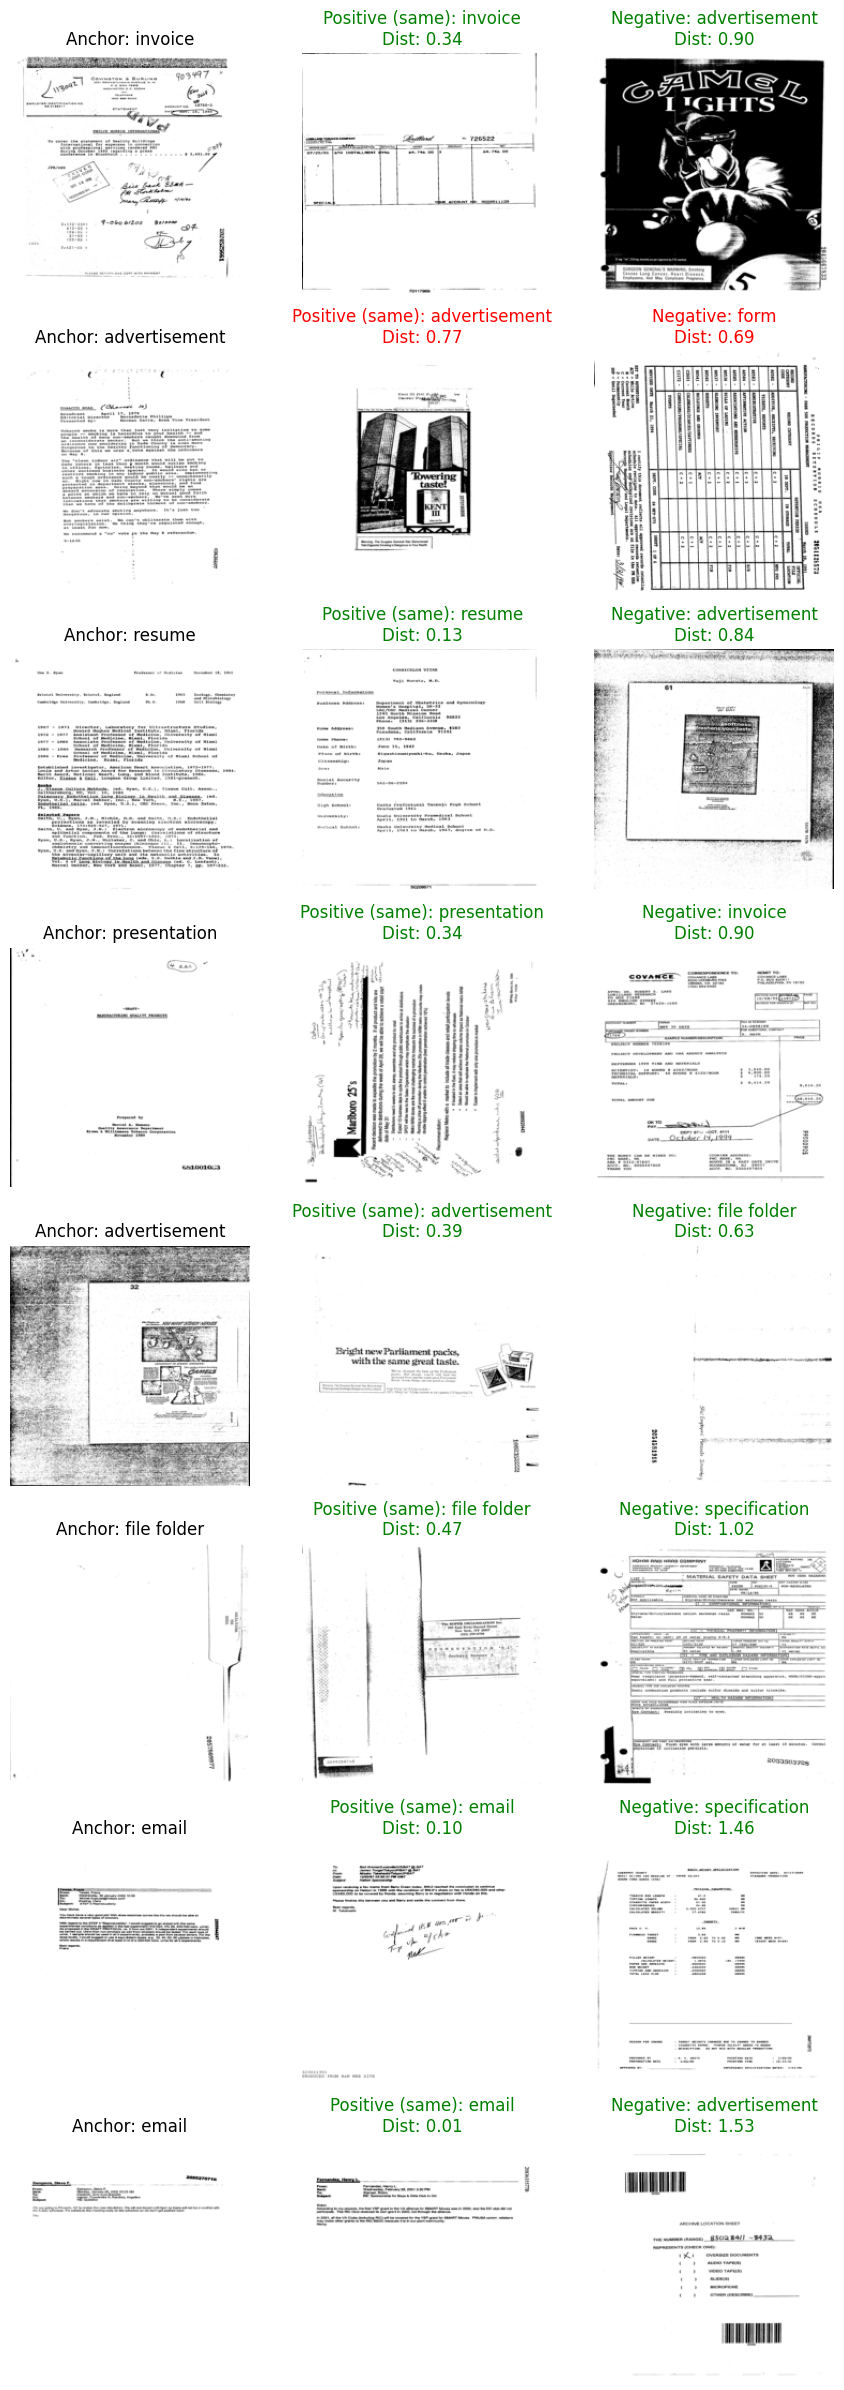

In [523]:
val_dataset = TripletLossDataset(split="val", transform=transform, max_samples=5000,
                                 allowed_classes=ALLOWED_CLASSES)
val_dataloader = DataLoader(dataset=val_dataset, shuffle=False, batch_size=8)
visualize_triplet_distances(net, val_dataloader, device, allowed_classes=ALLOWED_CLASSES, max_triplets=8)

# compute average distance

In [524]:
import torch
import torch.nn.functional as F
import numpy as np


def compute_average_distance(model, dataloader, device, max_batches=None):
    model.eval()
    all_dists = []

    with torch.inference_mode():
        for i, (a, p, n, *_) in enumerate(dataloader):
            a, p, n = a.to(device), p.to(device), n.to(device)
            a = F.normalize(model(a))
            p = F.normalize(model(p))
            n = F.normalize(model(n))

            pos_dist = F.pairwise_distance(a, p).cpu()
            neg_dist = F.pairwise_distance(a, n).cpu()

            all_dists.extend(pos_dist.cpu().numpy())
            all_dists.extend(neg_dist.cpu().numpy())

            if max_batches is not None and i + 1 >= max_batches:
                break

    avg_distance = np.mean(all_dists)
    print(f"Average distance (all pairs): {avg_distance:.3f}")
    return avg_distance

# distance histogram

In [525]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


def plot_distance_histogram(model, dataloader, device, max_batches=None, bins=50, threshold=1.0):
    model.eval()
    same_dists = []
    diff_dists = []

    correct_pos = 0
    correct_neg = 0

    with torch.inference_mode():
        for i, (a, p, n, *_) in enumerate(dataloader):
            a, p, n = a.to(device), p.to(device), n.to(device)

            a = F.normalize(model(a))
            p = F.normalize(model(p))
            n = F.normalize(model(n))

            pos_dist = F.pairwise_distance(a, p).cpu()
            neg_dist = F.pairwise_distance(a, n).cpu()
            # print(f"pos dist: {pos_dist}")
            # print(f"neg dist: {neg_dist}")

            for dist in pos_dist:
                # print(dist)
                if dist <= threshold:
                    correct_pos += 1
                same_dists.append(dist)
            for dist in neg_dist:
                if dist >= threshold:
                    correct_neg += 1
                diff_dists.append(dist)

            if max_batches is not None and i + 1 >= max_batches:
                break

    avg_same_dists = np.mean(same_dists)
    avg_diff_dists = np.mean(diff_dists)

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(same_dists, bins=bins, alpha=0.6, label='Gleiche Klasse', color='green')
    plt.hist(diff_dists, bins=bins, alpha=0.6, label='Unterschiedliche Klasse', color='red')
    plt.axvline(x=threshold, color='blue', linestyle='--', label=f'Mittelwert = {threshold:.5f}')
    plt.axvline(x=avg_same_dists, color='green', linestyle='--', label=f'Ø-Distanz gleiche Klasse = {avg_same_dists:.5f}')
    plt.axvline(x=avg_diff_dists, color='red', linestyle='--', label=f'Ø-Distanz unterschiedliche Klasse = {avg_diff_dists:.5f}')
    plt.xlabel("Euklidische Distanz (normalisiert)")
    plt.ylabel("Anzahl der Paare")
    plt.title("Verteilung der paarweisen Distanzen")
    plt.legend()
    plt.grid(True)
    os.makedirs(FOLDER_STR, exist_ok=True)
    plt.savefig(f"{FOLDER_STR}/distance_histogram.png")
    plt.show()

    # Accuracy
    same_accuracy = correct_pos / len(same_dists)
    diff_accuracy = correct_neg / len(diff_dists)
    overall_accuracy = (correct_pos + correct_neg) / (len(same_dists) + len(diff_dists))

    print(f"Avg distance (same): {avg_same_dists:.3f}")
    print(f"Avg distance (diff): {avg_diff_dists:.3f}")
    print(f"Accuracy (same class): {same_accuracy * 100:.2f}%")
    print(f"Accuracy (different class): {diff_accuracy * 100:.2f}%")
    print(f"Overall accuracy: {overall_accuracy * 100:.2f}%")

    return avg_same_dists, avg_diff_dists

Average distance (all pairs): 0.613


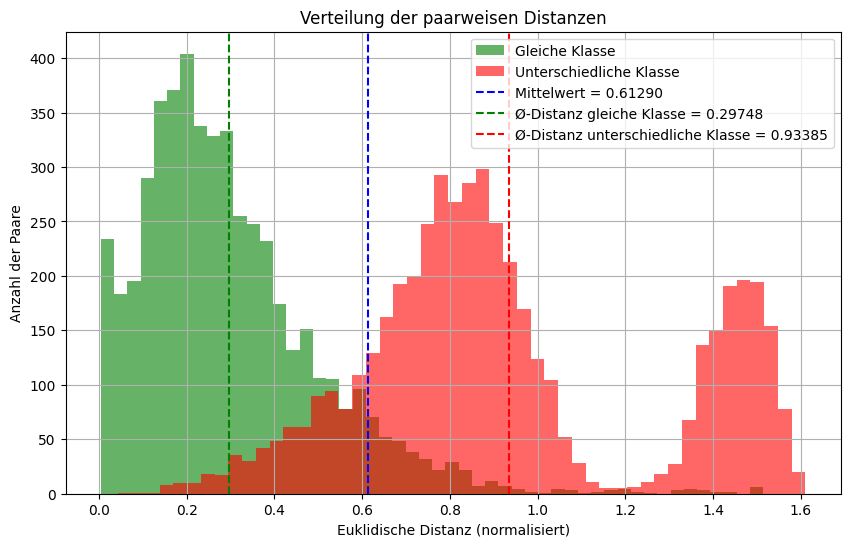

Avg distance (same): 0.297
Avg distance (diff): 0.934
Accuracy (same class): 92.58%
Accuracy (different class): 85.36%
Overall accuracy: 88.97%


In [526]:
thres = compute_average_distance(net, val_dataloader, device)
# print(thres)
avg_same_dists, avg_diff_dists = plot_distance_histogram(net, val_dataloader, device, threshold=thres)

# Class Template Dataset

In [527]:
from torch.utils.data import Dataset
import os
import random
from PIL import Image


class ClassTemplateDataset(Dataset):
    def __init__(self, cls: int, max_samples_per_class=1, transform=None, strategy=None, margin=0.1):

        assert strategy in [None, "RANDOM", "DISTANT"], "strategy must be RANDOM or DISTANT"

        root_dir = "data/RVL_CDIP/images"
        label_file = "data/RVL_CDIP/labels/val.txt"

        self.all_image_paths = []
        self.cls = cls
        self.transform = transform

        with open(label_file, 'r') as f:
            for line in f:
                # brich ab wenn du alle bilder hast
                if len(self.all_image_paths) >= max_samples_per_class:
                    print(f"fertig")
                    break

                # wähle bild zufällig
                rdm_image_path, rdm_image_label = line.strip().split()
                rdm_image_full_path = os.path.join(root_dir, rdm_image_path)
                rdm_image_label = int(rdm_image_label)
                if rdm_image_label != cls:
                    continue
                random_image = Image.open(rdm_image_full_path)
                random_image = self.transform(random_image).to(device)
                random_image = random_image.unsqueeze(0)

                if strategy == "RANDOM":
                    print(f"chosen random image")
                    self.all_image_paths.append((rdm_image_full_path, rdm_image_label))
                elif strategy == "DISTANT" and len(self.all_image_paths) == 0:
                    # wähle erstes bild -> berechne durchschnittliche distanz zu 20 bildern der gleichen klasse
                    avg_dist_of_random_image = 0.0
                    counter = 0
                    counter_limit = 20
                    for new_line in f:
                        if counter >= counter_limit:
                            break
                        new_img_path, new_img_label = new_line.strip().split()
                        new_img_full_path = os.path.join(root_dir, new_img_path)
                        new_img_label = int(new_img_label)
                        if new_img_label != cls or rdm_image_full_path == new_img_full_path:
                            continue
                        counter += 1

                        new_img = Image.open(new_img_full_path)
                        new_img = self.transform(new_img).to(device)
                        new_img = new_img.unsqueeze(0)

                        random_image_emb = F.normalize(net(random_image))
                        new_img_emb = F.normalize(net(new_img))
                        avg_dist_of_random_image += F.pairwise_distance(random_image_emb, new_img_emb)
                    avg_dist_of_random_image /= counter_limit

                    # wenn durchschnittliche distanz nicht im bereich des margin liegt wähle neues bild
                    if avg_dist_of_random_image <= avg_same_dists:
                        self.all_image_paths.append((rdm_image_full_path, rdm_image_label))
                    else:
                        continue
                elif strategy == "DISTANT" and len(self.all_image_paths) > 0:
                    # wähle nächstes bild -> berechne durchschnittliche distanz zu gesammelten bildern

                    current_imgs = [Image.open(path) for path, _ in self.all_image_paths]
                    current_imgs = [self.transform(img).to(device) for img in current_imgs]
                    current_imgs = [img.unsqueeze(0) for img in current_imgs]

                    avg_dist = 0.0
                    for img in current_imgs:
                        emb1 = F.normalize(net(img))
                        emb2 = F.normalize(net(random_image))
                        avg_dist += F.pairwise_distance(emb1, emb2)
                    avg_dist /= len(current_imgs)

                    min_dist = avg_same_dists
                    max_dist = thres - avg_same_dists
                    avg_dist = avg_dist.item()
                    print(f"min_dist: {min_dist}, avg_dist: {avg_dist}, max_dist: {max_dist}")


                    if min_dist <= avg_dist <= max_dist:
                        print(f"min_dist: {min_dist}, avg_dist: {avg_dist}, max_dist: {max_dist}")
                        self.all_image_paths.append((rdm_image_full_path, rdm_image_label))
                    else:
                        continue


    def get_class(self):
        return self.cls


    def __len__(self):
        return len(self.all_image_paths)


    def __getitem__(self, idx):
        img_path, img_class = self.all_image_paths[idx]
        img = Image.open(img_path)

        if self.transform:
            img = self.transform(img)

        img_class = 0
        return img, img_class


    def get_all_items(self):
        imgs = []
        for img_path, _ in self.all_image_paths:
            img = Image.open(img_path)

            if self.transform:
                img = self.transform(img)  # PIL -> Tensor (C,H,W)

            imgs.append(img)

        return imgs

# template sampling strategy/count

In [528]:
print(f"ALLOWED_CLASSES: {ALLOWED_CLASSES}")
print(f"NEW_ALLOWED_CLASSES: {NEW_ALLOWED_CLASSES}")
NEW_CLASSES_ONLY = list(set(NEW_ALLOWED_CLASSES) - set(ALLOWED_CLASSES))
print(f"NEW_CLASSES_ONLY: {NEW_CLASSES_ONLY}")

template_datasets = []
for cls in NEW_ALLOWED_CLASSES:
    template_strategy_choice = "RANDOM" if cls in NEW_CLASSES_ONLY else TEMPLATE_STRATEGY
    template_datasets.append(
        ClassTemplateDataset(cls,
                             max_samples_per_class=TEMPLATE_COUNT,
                             transform=transform, strategy=template_strategy_choice,
                             margin=avg_same_dists * 0.2)
    )

ALLOWED_CLASSES: [1, 2, 4, 7, 8, 11, 12, 14]
NEW_ALLOWED_CLASSES: [1, 2, 4, 7, 8, 10, 11, 12, 14]
NEW_CLASSES_ONLY: [10]
min_dist: 0.2974846363067627, avg_dist: 0.3014650046825409, max_dist: 0.3154151439666748
min_dist: 0.2974846363067627, avg_dist: 0.3014650046825409, max_dist: 0.3154151439666748
min_dist: 0.2974846363067627, avg_dist: 0.3524794280529022, max_dist: 0.3154151439666748
min_dist: 0.2974846363067627, avg_dist: 0.3101988434791565, max_dist: 0.3154151439666748
min_dist: 0.2974846363067627, avg_dist: 0.3101988434791565, max_dist: 0.3154151439666748
min_dist: 0.2974846363067627, avg_dist: 0.23877033591270447, max_dist: 0.3154151439666748
min_dist: 0.2974846363067627, avg_dist: 0.3092188239097595, max_dist: 0.3154151439666748
min_dist: 0.2974846363067627, avg_dist: 0.3092188239097595, max_dist: 0.3154151439666748
min_dist: 0.2974846363067627, avg_dist: 0.2454858124256134, max_dist: 0.3154151439666748
min_dist: 0.2974846363067627, avg_dist: 0.3095845580101013, max_dist: 0.31541

# classification

In [529]:
def predict_class_of_img(model: nn.Module, img, template_datasets, give_raw_value=False, plot_pairs=False):
    """

    :param model: the model making the predictions
    :param img: image to be predicted on (shape must be [1, 1, 224, 224])
    :param template_datasets: list of datasets where the templates live
    :param threshold: threshold defining how confident the model must be to predict a class
    :return: the predicted class (0-15) of the given image, if no prediction could be made confidently it returns -1
    """
    assert img.shape == torch.Size(
        [1, 1, 224, 224]), "image shape must be [1, 1, 224, 224], hint: an unsqueeze(0) could fix it"
    model.eval()

    best_class = None
    best_mean_dist = float("inf")

    with torch.inference_mode():
        for cls_data in template_datasets:

            cls_data_dists = []
            for img2 in cls_data.get_all_items():
                img2 = img2.unsqueeze(0)  # Batch dimension für model hinzufügen

                img, img2 = img.to(device), img2.to(device)
                emb1 = F.normalize(model(img))
                emb2 = F.normalize(model(img2))
                dists = F.pairwise_distance(emb1, emb2)

                cls_data_dists.append(dists)

            mean_dist = torch.cat(cls_data_dists, dim=0).mean().item()

            if plot_pairs:
                # Tensor -> NumPy (CPU)
                img_np = img.squeeze().cpu().numpy()

                # Kleineres einzelnes Bild
                fig, ax = plt.subplots(figsize=(2, 2))  # kleineres Format
                ax.imshow(img_np, cmap="gray")
                ax.axis("off")

                # Titel mit Distanz und Klasse
                ax.set_title(f"Distanz: {mean_dist:.4f}\nKlasse: {cls_data.get_class()}", fontsize=8)

                plt.tight_layout()
                plt.show()

            if mean_dist <= best_mean_dist:
                best_mean_dist = mean_dist
                best_class = cls_data.get_class()

        if give_raw_value:
            return best_mean_dist
        return best_class


In [530]:
def print_pred(pred):
    print(f"{pred}: {class_names[pred]}")

## preparing the dataloader for classification

In [531]:
dataset_with_new_classes = TripletLossDataset(
    allowed_classes=NEW_ALLOWED_CLASSES,
    split="val",
    transform=transform,
    max_samples_per_class=200
)
dataloader_with_new_classes = DataLoader(
    dataset=dataset_with_new_classes,
    batch_size=1,
    shuffle=False
)

for label, images in dataset_with_new_classes.label_to_images.items():
    print(f"Label: {label}, Anzahl Bilder: {len(images)}")

Label: 11, Anzahl Bilder: 200
Label: 4, Anzahl Bilder: 200
Label: 14, Anzahl Bilder: 200
Label: 12, Anzahl Bilder: 200
Label: 10, Anzahl Bilder: 200
Label: 8, Anzahl Bilder: 200
Label: 2, Anzahl Bilder: 200
Label: 1, Anzahl Bilder: 200
Label: 7, Anzahl Bilder: 200


#### compute average distance of images from known classes

In [532]:
# dataset_with_old_classes = TripletLossDataset(allowed_classes=ALLOWED_CLASSES, split="val", transform=transform,
#                                               max_samples_per_class=200)
# dataloader_with_old_classes = DataLoader(dataset=dataset_with_old_classes, batch_size=1, shuffle=False)
#
# dists = []
# net.eval()
# with torch.inference_mode():
#     for batch in dataloader_with_old_classes:
#         a, p, n, a_cls, n_cls = batch
#         mapped_a_cls = ALLOWED_CLASSES[a_cls]
#         mapped_n_cls = ALLOWED_CLASSES[n_cls]
#
#         dist1 = predict_class_of_img(net, a, template_datasets, give_raw_value=True)
#         dist2 = predict_class_of_img(net, n, template_datasets, give_raw_value=True)
#         dists.append(dist1)
#         dists.append(dist2)

In [533]:
# mean_dist = np.mean(dists)
# print(mean_dist)

## create the confusion matrices


================= Threshold: (8_DISTANT_5) =================


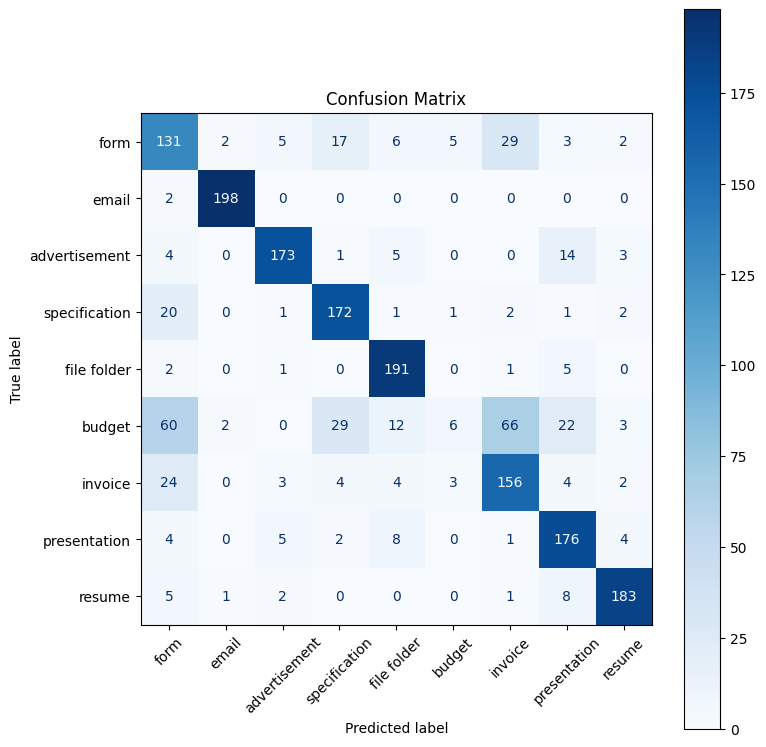

Klasse 'form':
  -> Recall:    65.50%
  -> Precision: 51.98%
Klasse 'email':
  -> Recall:    99.00%
  -> Precision: 97.54%
Klasse 'advertisement':
  -> Recall:    86.50%
  -> Precision: 91.05%
Klasse 'specification':
  -> Recall:    86.00%
  -> Precision: 76.44%
Klasse 'file folder':
  -> Recall:    95.50%
  -> Precision: 84.14%
Klasse 'budget':
  -> Recall:    3.00%
  -> Precision: 40.00%
Klasse 'invoice':
  -> Recall:    78.00%
  -> Precision: 60.94%
Klasse 'presentation':
  -> Recall:    88.00%
  -> Precision: 75.54%
Klasse 'resume':
  -> Recall:    91.50%
  -> Precision: 91.96%
Gesamt-Accuracy: 77.00%


In [534]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, accuracy_score
import matplotlib.pyplot as plt

class_to_idx = {cls: i for i, cls in enumerate(NEW_ALLOWED_CLASSES)}
idx_to_class = dict(enumerate(NEW_ALLOWED_CLASSES))

MAX_IMAGES = 100000

os.makedirs(FOLDER_STR, exist_ok=True)
output_file = os.path.join(FOLDER_STR, "metrics.txt")

with open(output_file, "w", encoding="utf-8") as f:
    filename = f"{len(ALLOWED_CLASSES)}_{TEMPLATE_STRATEGY}_{TEMPLATE_COUNT}"
    print(f"\n================= Threshold: ({filename}) =================")
    f.write(f"\n================= Threshold: ({filename}) =================\n")

    all_preds, all_labels = [], []
    img_count = 0

    with torch.inference_mode():
        for batch in dataloader_with_new_classes:
            anc, _, _, anc_class, _ = batch

            for img, lbl_idx in zip(anc, anc_class):
                if img_count >= MAX_IMAGES:
                    break

                original_cls = idx_to_class[lbl_idx.item()]
                mapped_true = class_to_idx[original_cls]
                all_labels.append(mapped_true)

                # shit = (original_cls in NEW_CLASSES_ONLY)
                shit = False

                img = img.unsqueeze(0).to(device)
                pred_cls = predict_class_of_img(net, img, template_datasets, plot_pairs=shit)
                mapped_pred = class_to_idx[pred_cls]
                all_preds.append(mapped_pred)

                img_count += 1
            if img_count >= MAX_IMAGES:
                break

    known_ids = list(class_to_idx.values())
    label_names = [class_names[c] for c in NEW_ALLOWED_CLASSES]

    cm = confusion_matrix(all_labels, all_preds, labels=known_ids)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
    plt.title(f"Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{FOLDER_STR}/{filename}.png")
    plt.show()

    recall_per_class = recall_score(all_labels, all_preds, labels=known_ids, average=None)
    precision_per_class = precision_score(all_labels, all_preds, labels=known_ids, average=None)

    for i, class_name in enumerate(label_names):
        recall_str = f"{recall_per_class[i]:.2%}"
        precision_str = f"{precision_per_class[i]:.2%}"
        print(f"Klasse '{class_name}':")
        print(f"  -> Recall:    {recall_str}")
        print(f"  -> Precision: {precision_str}")
        f.write(f"Klasse '{class_name}':\n")
        f.write(f"  -> Recall:    {recall_str}\n")
        f.write(f"  -> Precision: {precision_str}\n")

    overall_accuracy = accuracy_score(all_labels, all_preds)
    accuracy_str = f"{overall_accuracy:.2%}"
    print(f"Gesamt-Accuracy: {accuracy_str}")
    f.write(f"Gesamt-Accuracy: {accuracy_str}\n")



# end of doc